# 04 — Avaliação e Interpretação

Aqui a análise deixa de ser técnica e passa a ser de negócio.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sys.path.append(str(Path("..").resolve()))
from src.config import (
    RANDOM_STATE, DATA_RAW, DATA_PROCESSED, RESULTS, FIGURES, METRICS, MODELS,
    RAW_FILE, PROCESSED_FILE, ID_COL, TARGET, TARGET_BIN, QUALITY_THRESHOLD,
    TEST_SIZE, CV_FOLDS,
)

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100
import joblib
from sklearn.model_selection import train_test_split

from src.evaluation import (
    score, comparison_table, plot_confusion_matrices, plot_roc_curves, feature_importance,
)

In [2]:
# Reconstrói o mesmo split do notebook 03 — determinístico graças ao RANDOM_STATE fixo,
# não precisa persistir X_test/y_test em disco.
df = pd.read_csv(PROCESSED_FILE)
drop_cols = [TARGET, TARGET_BIN]
X = df.drop(columns=drop_cols)
y = df[TARGET_BIN]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE
)

modelos = {
    nome: joblib.load(MODELS / f"{nome}.joblib")
    for nome in ("logistic_regression", "random_forest", "gradient_boosting")
}
X_test.shape

(229, 13)

## 1. Métricas no conjunto de teste

Em bases desbalanceadas, a acurácia isolada não constitui critério suficiente de
avaliação.

In [3]:
resultados = {}
for nome, modelo in modelos.items():
    y_pred = modelo.predict(X_test)
    y_proba = modelo.predict_proba(X_test)[:, 1]
    resultados[nome] = score(y_test, y_pred, y_proba)

tabela = comparison_table(resultados, filename="metricas_teste.csv")
tabela

,accuracy,precision,recall,f1,roc_auc
random_forest,0.8952,0.6111,0.6875,0.6471,0.9006
gradient_boosting,0.9039,0.6923,0.5625,0.6207,0.8683
logistic_regression,0.7991,0.3793,0.6875,0.4889,0.8499


**Leitura:** no conjunto de teste (229 amostras, não utilizadas em treino ou validação
cruzada), o `random_forest` apresenta o melhor F1 (0,6471) e a melhor AUC-ROC (0,9006),
à frente do `gradient_boosting` (F1 0,6207 / AUC 0,8683) e do `logistic_regression`
(F1 0,4889 / AUC 0,8499). O resultado confirma, sobre dados não utilizados na seleção do
modelo, o que a validação cruzada já sugeria: os dois ensembles de árvore superam o
modelo linear, e o Random Forest constitui o modelo final adotado neste projeto.

Observa-se diferença expressiva de **precisão** entre os modelos: o
`logistic_regression` classifica corretamente 37,9% dos casos que aponta como alta
qualidade, incorrendo em elevado número de falsos positivos, contra 61,1% do
`random_forest` e 69,2% do `gradient_boosting`. Em contrapartida,
`logistic_regression` e `random_forest` apresentam **revocação** equivalente (68,75%),
identificando a mesma proporção dos vinhos efetivamente classificados como de alta
qualidade, enquanto o `gradient_boosting` recupera parcela menor (56,25%). É justamente
esse equilíbrio entre o erro por excesso (baixa precisão) e o erro por omissão (baixa
revocação) que o F1 sintetiza, razão pela qual orienta a seleção do modelo em lugar da
acurácia ou da precisão isoladas.

## 2. Justificativa das métricas

Com aproximadamente 14% de vinhos de alta qualidade no conjunto de teste, um
classificador que atribuísse a todos os casos a classe majoritária alcançaria 86% de
acurácia sem identificar corretamente nenhum vinho de alta qualidade. A acurácia de
89,5% obtida pelo Random Forest só se torna informativa quando confrontada com esse
patamar de referência e, ainda assim, não evidencia o que é relevante ao problema:
a proporção de vinhos efetivamente bons que o modelo recupera (revocação) e a frequência
com que classifica indevidamente um vinho como de alta qualidade (complemento da
precisão). Por essa razão, adotam-se como métricas de comparação o **F1** — que equilibra
as duas dimensões — e a **AUC-ROC** — que mensura a capacidade discriminatória do modelo
independentemente do limiar de decisão —, reportando-se precisão e revocação
separadamente para explicitar a composição do F1 de cada modelo.

Quanto ao custo relativo dos erros, a resposta depende da aplicação pretendida. Em um
cenário de **triagem** — sinalização de lotes candidatos a uma linha premium ou a exame
sensorial mais oneroso conduzido por enólogo —, o falso negativo, que descarta um vinho
efetivamente promissor, representa o erro mais custoso, por implicar perda de
oportunidade de valorização não recuperável; o falso positivo, que encaminha um vinho
mediano para reavaliação, onera apenas o tempo adicional de análise. Nesse contexto, a
revocação assume peso superior ao da precisão, e a equivalência entre Random Forest e
Regressão Logística nessa métrica (68,75%) constituiria argumento para reconsiderar o
modelo linear apesar do F1 inferior — decisão que compete à área de negócio, e não
exclusivamente ao critério técnico.

## 3. Matriz de confusão

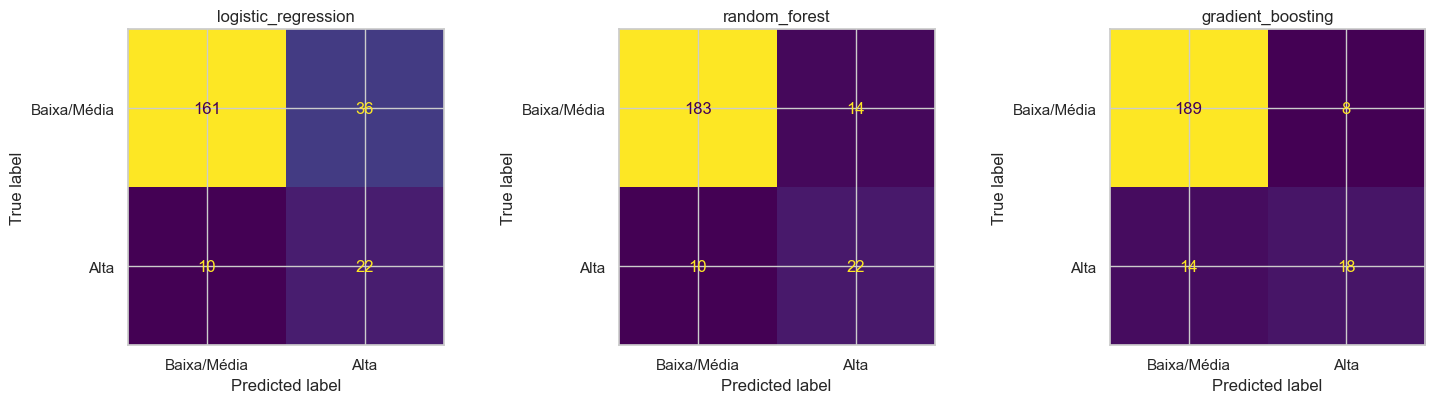

In [4]:
plot_confusion_matrices(modelos, X_test, y_test, path=FIGURES / "06_matrizes_confusao.png")
plt.show()

**Leitura:** das 229 amostras de teste, 197 pertencem à classe baixa/média e 32 à classe
alta qualidade. O `random_forest` registra 14 falsos positivos e 10 falsos negativos,
identificando corretamente 22 dos 32 vinhos de alta qualidade; o `gradient_boosting`
incorre em menos falsos positivos (8), porém em mais falsos negativos (14, recuperando
18 dos 32 casos positivos) — comportamento mais restritivo na atribuição da classe alta
qualidade, o que explica sua precisão superior e sua revocação inferior. O
`logistic_regression` apresenta comportamento oposto: registra apenas 10 falsos negativos
(revocação equivalente à do Random Forest), mas 36 falsos positivos, classificando
indevidamente como de alta qualidade um número elevado de vinhos medianos.

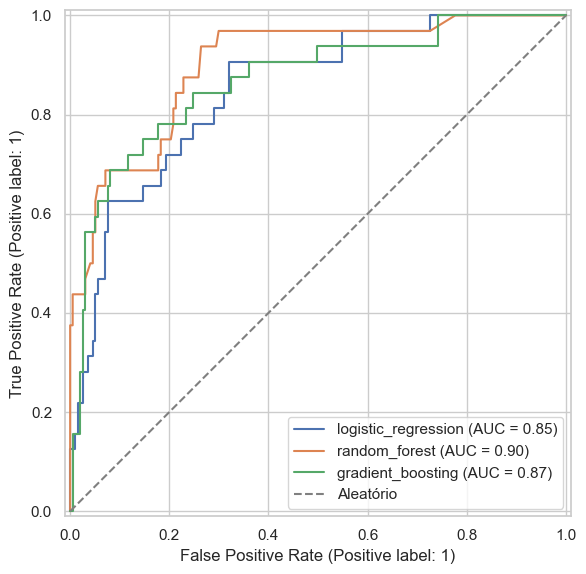

In [5]:
plot_roc_curves(modelos, X_test, y_test, path=FIGURES / "07_curvas_roc.png")
plt.show()

**Leitura:** as três curvas ficam bem acima da diagonal de um classificador
aleatório, confirmando que todos os modelos aprenderam sinal real da base. `random_forest`
(AUC 0,9006) e `gradient_boosting` (AUC 0,8683) têm curvas próximas uma da outra e
acima da `logistic_regression` (AUC 0,8499) na maior parte dos limiares — o que reforça,
de outro ângulo, a escolha do Random Forest como modelo final: ele não é só o melhor no
limiar padrão de 0,5 (usado para calcular a matriz de confusão e o F1 acima), mas também
o mais discriminativo de forma geral, o que dá mais liberdade para ajustar o limiar de
decisão depois, conforme o apetite de risco do negócio (mais recall vs. mais precisão),
sem perder muito desempenho.

## 4. Importância das variáveis

In [6]:
melhor_modelo_nome = tabela["f1"].idxmax()
melhor_modelo = modelos[melhor_modelo_nome]
print("Melhor modelo (por F1 no teste):", melhor_modelo_nome)

imp = feature_importance(melhor_modelo, X_test.columns)
imp.round(4)

Melhor modelo (por F1 no teste): random_forest


alcohol_sulphates       0.1599
alcohol                 0.1501
acidity_ratio           0.1115
citric acid             0.0916
sulphates               0.0837
volatile acidity        0.0810
density                 0.0614
total sulfur dioxide    0.0535
fixed acidity           0.0469
chlorides               0.0463
pH                      0.0420
free sulfur dioxide     0.0362
residual sugar          0.0359
dtype: float64

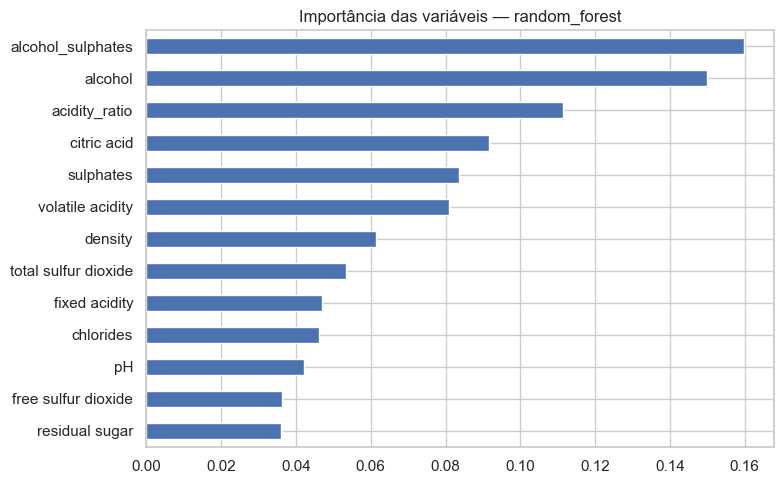

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
imp.sort_values().plot.barh(ax=ax, color="#4C72B0")
ax.set_title(f"Importância das variáveis — {melhor_modelo_nome}")
fig.tight_layout()
fig.savefig(FIGURES / "08_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

**Leitura:** as duas variáveis de maior importância para o Random Forest são
precisamente os atributos derivados no notebook 02 — `alcohol_sulphates` (0,1599) e
`acidity_ratio` (0,1115) —, intercalados por `alcohol` (0,1501), já identificado na
análise exploratória como a variável de maior correlação com a qualidade. Em conjunto,
essas três variáveis respondem por aproximadamente 40% da importância total atribuída
pelo modelo, o que evidencia o ganho efetivo obtido com a engenharia de atributos
realizada na etapa de pré-processamento. Seguem-se `citric acid` (0,0916), `sulphates`
(0,0837) e `volatile acidity` (0,0810), todas previamente apontadas como relevantes na
análise de correlação (notebook 01, seção 3). As variáveis de distribuição mais assimétrica
e maior incidência de outliers — `chlorides`, `residual sugar` e `free sulfur dioxide` —
figuram entre as de menor importância, resultado coerente com a natureza dessas
observações, cuja raridade não implica poder discriminatório.

## 5. Implicações práticas

Os três fatores que mais separam um vinho "alta qualidade" de um vinho comum, segundo o
modelo, são **teor alcoólico**, **sulfatos** e **o equilíbrio entre acidez fixa e acidez
volátil**. Na prática, isso indica três alavancas de produção para a equipe de enologia
monitorar de perto: (1) o processo de fermentação, que determina o teor alcoólico final;
(2) a dosagem de sulfatos, usada como conservante/antioxidante, que aparece de forma
consistente associada a notas mais altas dentro da faixa observada nesta base; e (3) o
controle de acidez volátil — presença de ácido acético acima do desejável está entre os
fatores mais associados a notas baixas, e costuma sinalizar problema no processo
(contaminação bacteriana, oxidação) mais do que característica da uva.

Operacionalmente, o modelo pode ser usado como uma **triagem de baixo custo**: em vez de
um enólogo avaliar sensorialmente todos os lotes, o modelo pode apontar os lotes com
maior probabilidade de nota alta a partir de medições físico-químicas (mais baratas e
rápidas de obter do que uma degustação formal), priorizando o tempo do especialista
humano nos lotes mais promissores — sem substituir a avaliação sensorial, que continua
sendo a fonte da nota real.

## 6. Limitações

- **Dimensão reduzida da base e restrição a um único tipo de vinho.** As 1.143 amostras
  referem-se a vinho **tinto** — as faixas observadas de acidez, cloretos e álcool são
  compatíveis com a variedade tinta do Wine Quality Dataset —, sem registro de safra,
  casta ou região. O modelo, portanto, não é generalizável para vinhos brancos nem para
  produtores cujos processos difiram substancialmente dos representados no conjunto.
- **Baixa representatividade dos extremos da escala.** A nota 8 conta com apenas 16
  amostras em toda a base (1,40%), de modo que o modelo dispõe de pouquíssimos exemplos
  desse patamar, reduzindo a confiabilidade das previsões próximas ao topo da escala.
- **Subjetividade da variável resposta.** A variável `quality` corresponde a uma nota
  atribuída por especialistas humanos, sujeita a variação entre avaliadores; o modelo
  reproduz esse julgamento agregado, e não uma medida objetiva de qualidade.
- **Trabalhos futuros:** ampliar a coleta de amostras, sobretudo nos extremos 3, 4 e 8;
  avaliar técnicas de balanceamento como SMOTE, em complemento ao `class_weight="balanced"`
  já empregado; calibrar o limiar de decisão conforme o custo real associado a falsos
  positivos e falsos negativos no contexto de negócio (seção 2); e validar o modelo em
  safra ou lote não representado na amostra de treinamento antes de qualquer uso
  produtivo.